# FFT / DCT Image Processing Basics

This notebook compares FFT and DCT based image processing.

## Goals

- Load and visualize images
- Analyze FFT frequency spectrum
- Analyze DCT coefficients
- Reconstruct images using IFFT / IDCT

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.fft import dctn, idctn


import os

print(os.getcwd())

d:\works\projects\FrequencyVisionLab\notebooks


In [57]:
IMAGE_PATHS = [
    "imgs/test0.jpg",
    "imgs/test1.jpg",
]

images = []

for path in IMAGE_PATHS:
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(path)

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    images.append({
        "path": path,
        "rgb": rgb,
        "gray": gray,
    })

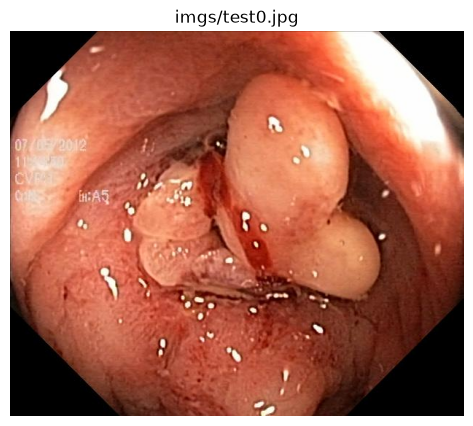

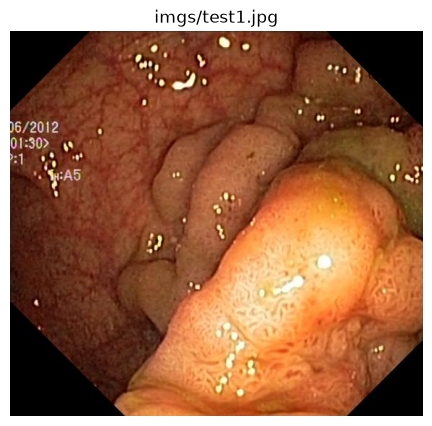

In [58]:
for item in images:
    plt.figure(figsize=(7, 5))
    plt.imshow(item["rgb"])
    plt.title(item["path"])
    plt.axis("off")
    plt.show()

# FFT

The Fast Fourier Transform converts image data from the spatial domain into the frequency domain.

After applying `fftshift()`, low-frequency components are located near the center of the spectrum.

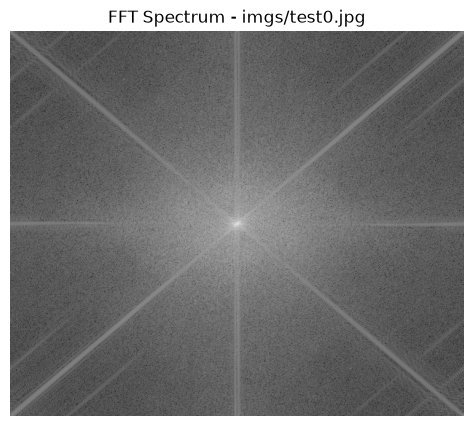

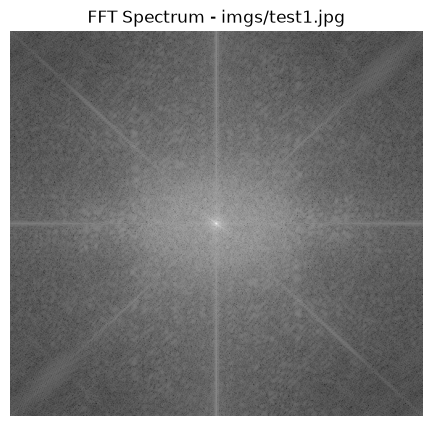

In [59]:
def fft_analysis(image):
    fft = np.fft.fft2(image)

    fft_shift = np.fft.fftshift(fft)

    magnitude = np.log1p(
        np.abs(fft_shift)
    )

    return fft_shift, magnitude


for item in images:
    fft_shift, magnitude = fft_analysis(
        item["gray"]
    )

    plt.figure(figsize=(8, 5))

    plt.imshow(
        magnitude,
        cmap="gray"
    )

    plt.title(
        f"FFT Spectrum - {item['path']}"
    )

    plt.axis("off")
    plt.show()

## FFT Reconstruction

No frequency components are modified in this experiment.

The original image is reconstructed using IFFT.

In [60]:
def fft_reconstruct(fft_shift):
    fft_ishift = np.fft.ifftshift(
        fft_shift
    )

    reconstructed = np.fft.ifft2(
        fft_ishift
    )

    return np.real(reconstructed)

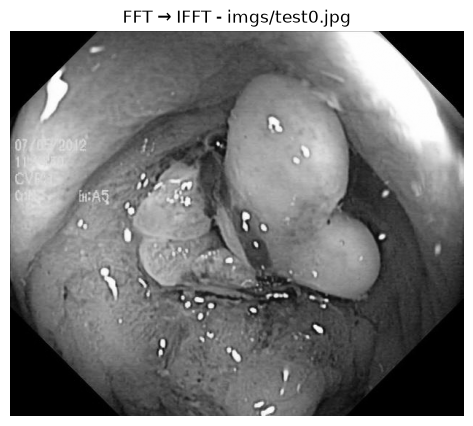

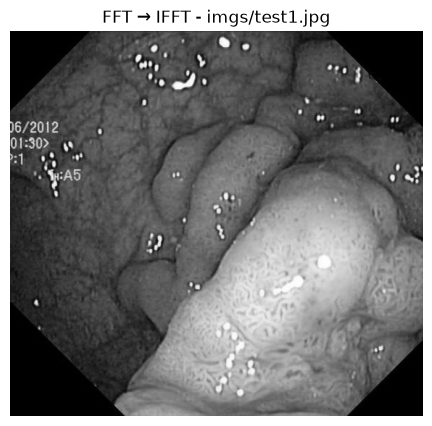

In [61]:
for item in images:
    fft_shift, _ = fft_analysis(
        item["gray"]
    )

    reconstructed = fft_reconstruct(
        fft_shift
    )

    plt.figure(figsize=(8, 5))

    plt.imshow(
        reconstructed,
        cmap="gray"
    )

    plt.title(
        f"FFT → IFFT - {item['path']}"
    )

    plt.axis("off")
    plt.show()

# FFT Original vs Reconstruction

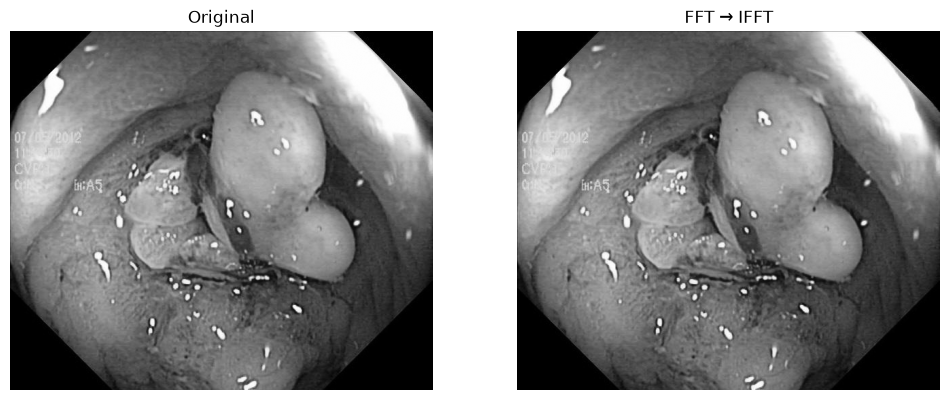

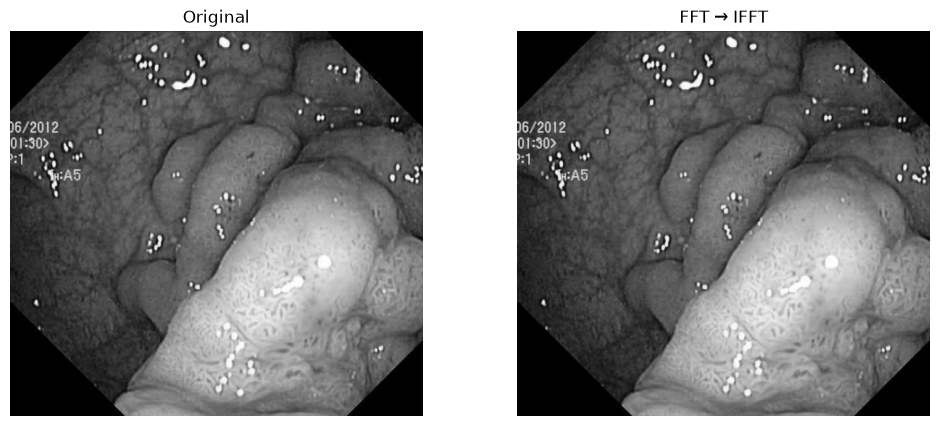

In [62]:
for item in images:
    fft_shift, _ = fft_analysis(
        item["gray"]
    )

    reconstructed = fft_reconstruct(
        fft_shift
    )

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(
        item["gray"],
        cmap="gray"
    )
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(
        reconstructed,
        cmap="gray"
    )
    plt.title("FFT → IFFT")
    plt.axis("off")

    plt.show()

# DCT

The Discrete Cosine Transform converts spatial image data into real-valued frequency coefficients.

Unlike FFT, DCT uses cosine basis functions only.

Low-frequency coefficients are located near the upper-left corner.

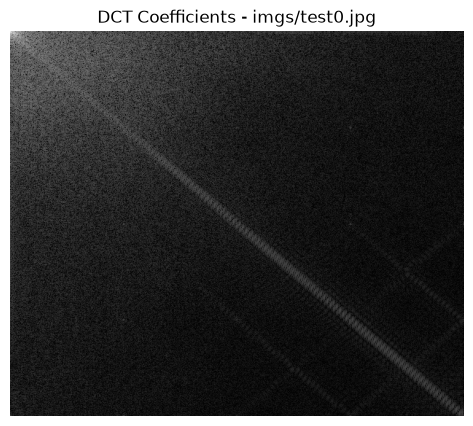

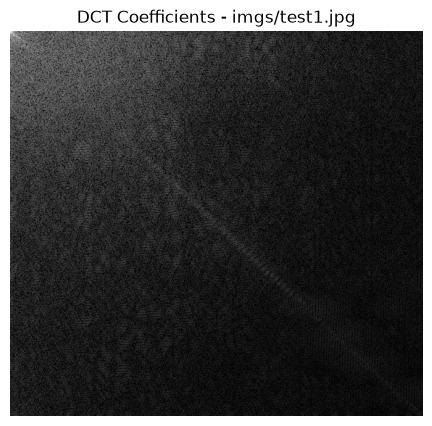

In [63]:
def dct_analysis(image):
    image_float = image.astype(
        np.float32
    )

    coefficients = dctn(
        image_float,
        type=2,
        norm="ortho"
    )

    magnitude = np.log1p(
        np.abs(coefficients)
    )

    return coefficients, magnitude


for item in images:
    coefficients, magnitude = dct_analysis(
        item["gray"]
    )

    plt.figure(figsize=(8, 5))

    plt.imshow(
        magnitude,
        cmap="gray"
    )

    plt.title(
        f"DCT Coefficients - {item['path']}"
    )

    plt.axis("off")
    plt.show()

## DCT Reconstruction

The DCT coefficients are reconstructed using IDCT without modification.

In [64]:
def dct_reconstruct(coefficients):
    reconstructed = idctn(
        coefficients,
        type=2,
        norm="ortho"
    )

    return reconstructed

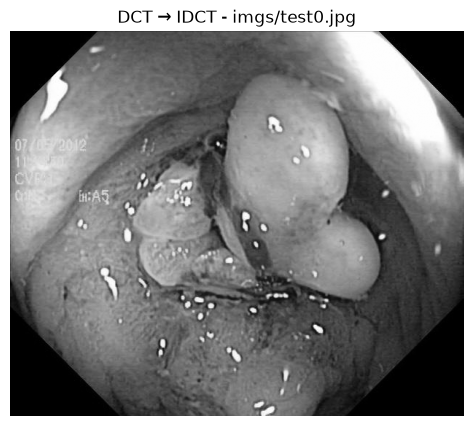

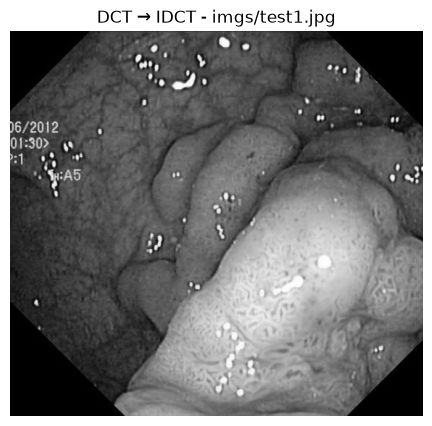

In [65]:
for item in images:
    coefficients, _ = dct_analysis(
        item["gray"]
    )

    reconstructed = dct_reconstruct(
        coefficients
    )

    plt.figure(figsize=(8, 5))

    plt.imshow(
        reconstructed,
        cmap="gray"
    )

    plt.title(
        f"DCT → IDCT - {item['path']}"
    )

    plt.axis("off")
    plt.show()

DCT Original vs Reconstruction

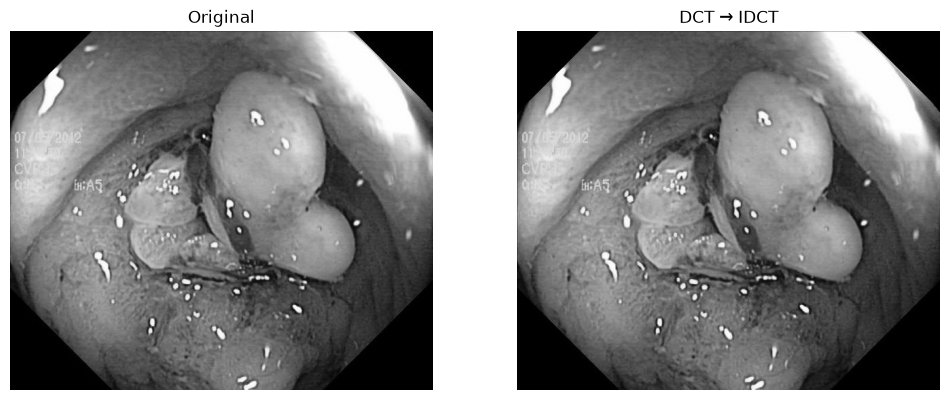

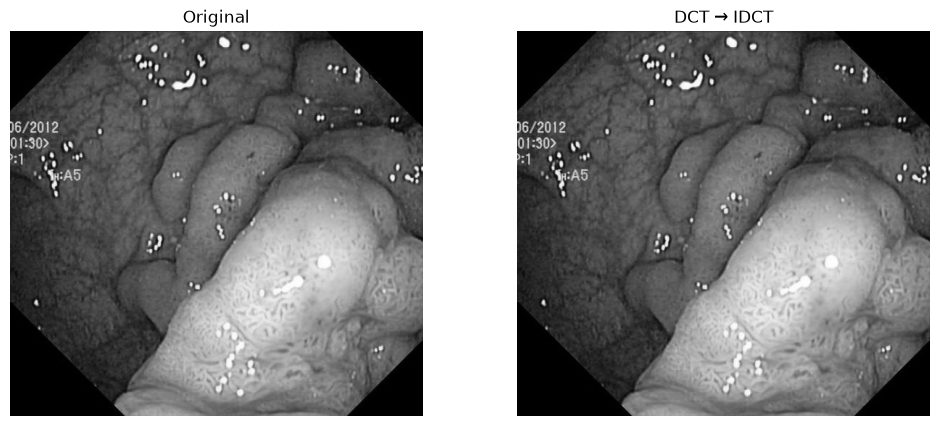

In [66]:
for item in images:
    coefficients, _ = dct_analysis(
        item["gray"]
    )

    reconstructed = dct_reconstruct(
        coefficients
    )

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(
        item["gray"],
        cmap="gray"
    )
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(
        reconstructed,
        cmap="gray"
    )
    plt.title("DCT → IDCT")
    plt.axis("off")

    plt.show()

# FFT vs DCT

| Feature | FFT | DCT |
|---|---|---|
| Coefficients | Complex | Real |
| Basis | Sine + Cosine | Cosine |
| Low Frequency Position | Center after `fftshift()` | Upper-left |
| Phase Information | Available | No explicit phase |
| Reconstruction | IFFT | IDCT |
| Typical Use | Frequency analysis | Compression / frequency processing |

## Initial Observation

Both FFT and DCT can represent image information in the frequency domain.

FFT explicitly provides magnitude and phase information.

DCT concentrates image energy into low-frequency coefficients and is widely used in image and video compression.

No filtering has been applied yet.

The next experiment will apply:

- Low-Pass Filter
- High-Pass Filter
- Frequency component reduction